In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import VotingClassifier

In [64]:
ruta_dir = os.getcwd()
df=pd.read_parquet(os.path.join(ruta_dir,"..","data","c5_train_test.parquet"))

In [65]:
df

,codigo_cierre,longitud,latitud,dia_semana_Domingo,dia_semana_Jueves,dia_semana_Lunes,dia_semana_Martes,dia_semana_Miércoles,dia_semana_Sábado,dia_semana_Viernes,...,mes_9,mes_10,mes_11,mes_12,periodo_madrugada,periodo_mañana,periodo_medio día,periodo_tarde,fin_semana_0,fin_semana_1
0,1,-99.061040,19.380900,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
1,1,-99.103420,19.490530,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,True,False
4,1,-99.191040,19.363360,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,True,False
5,1,-99.054880,19.295440,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,True,False
6,1,-99.197810,19.482380,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115075,1,-99.087270,19.320600,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2115076,1,-99.125200,19.428723,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2115077,0,-99.119881,19.380011,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2115078,0,-99.080981,19.369412,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False


In [66]:
y=df["codigo_cierre"]
x=df.drop(columns=["codigo_cierre"])

In [67]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [68]:
normalizer = StandardScaler()
normalizer.fit(x_train[["latitud","longitud"]])



StandardScaler()

In [69]:
x_train[["latitud","longitud"]]=normalizer.transform(x_train[["latitud","longitud"]])
x_test[["latitud","longitud"]]=normalizer.transform(x_test[["latitud","longitud"]])

In [70]:
modelo=LogisticRegression(max_iter=1000)
modelo.fit(x_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [71]:
y_pred_proba=modelo.predict_proba(x_test)[:,1]
y_pred=(y_pred_proba>0.3).astype(int)

In [72]:
reporte=pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
reporte

,precision,recall,f1-score,support
0,0.735009,0.381361,0.502170,247841.000000
1,0.475787,0.803297,0.597612,173236.000000
accuracy,0.554951,0.554951,0.554951,0.554951
macro avg,0.605398,0.592329,0.549891,421077.000000
weighted avg,0.628362,0.554951,0.541436,421077.000000


 Exactitud (Accuracy): 0.5549507572249256

 Matriz de confusión:
 [[ 94517 153324]
 [ 34076 139160]]


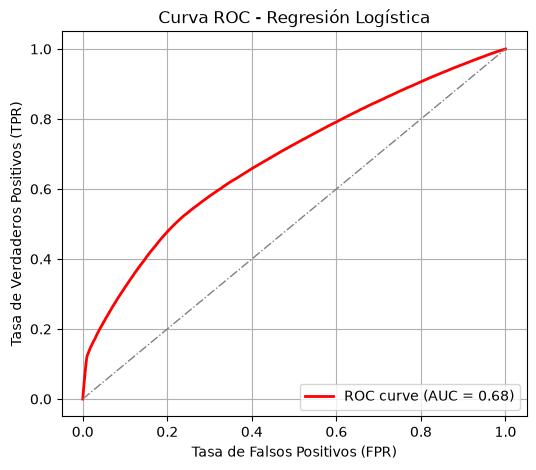

In [73]:

print(" Exactitud (Accuracy):", accuracy_score(y_test, y_pred))
print("\n Matriz de confusión:\n", confusion_matrix(y_test, y_pred))


# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='-.')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [74]:
modelo2=RandomForestClassifier(n_estimators=100, random_state=42,n_jobs=-1, max_depth=10, min_samples_split=5, min_samples_leaf=2)
modelo2.fit(x_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [85]:
y_pred_prob1=modelo2.predict_proba(x_test)[:,1]
y_pred1=(y_pred_prob1>0.3).astype(int)

In [86]:
reporte=pd.DataFrame(classification_report(y_test, y_pred1, output_dict=True)).transpose()
reporte

,precision,recall,f1-score,support
0,0.742474,0.395064,0.515718,247841.000000
1,0.481582,0.803961,0.602350,173236.000000
accuracy,0.563289,0.563289,0.563289,0.563289
macro avg,0.612028,0.599512,0.559034,421077.000000
weighted avg,0.635140,0.563289,0.551360,421077.000000


 Exactitud (Accuracy): 0.5632888996549325

 Matriz de confusión:
 [[ 97913 149928]
 [ 33961 139275]]


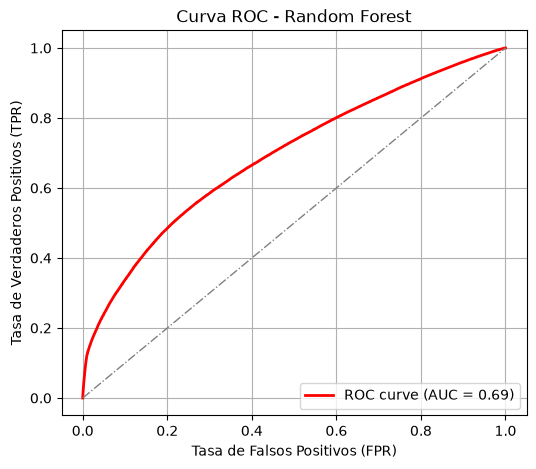

In [98]:
print(" Exactitud (Accuracy):", accuracy_score(y_test, y_pred1))
print("\n Matriz de confusión:\n", confusion_matrix(y_test, y_pred1))


# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='-.')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [87]:
modelo3=XGBClassifier(n_estimators=100, random_state=42, max_depth=10, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8)
modelo3.fit(x_train,y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [82]:
y_pred_prob3=modelo3.predict_proba(x_test)[:,1]
y_pred3=(y_pred_prob3>0.3).astype(int)

In [83]:
reporte=pd.DataFrame(classification_report(y_test, y_pred3, output_dict=True)).transpose()
reporte

,precision,recall,f1-score,support
0,0.742474,0.395064,0.515718,247841.000000
1,0.481582,0.803961,0.602350,173236.000000
accuracy,0.563289,0.563289,0.563289,0.563289
macro avg,0.612028,0.599512,0.559034,421077.000000
weighted avg,0.635140,0.563289,0.551360,421077.000000


 Exactitud (Accuracy): 0.5632888996549325

 Matriz de confusión:
 [[ 97913 149928]
 [ 33961 139275]]


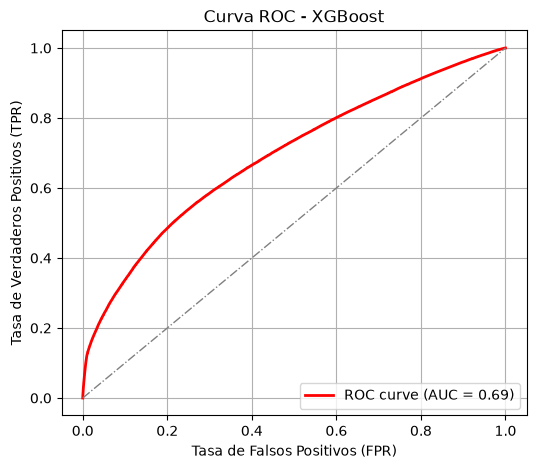

In [99]:
print(" Exactitud (Accuracy):", accuracy_score(y_test, y_pred3))
print("\n Matriz de confusión:\n", confusion_matrix(y_test, y_pred3))


# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob3)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='-.')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - XGBoost')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [103]:
soft_voting = VotingClassifier(
    estimators=[('Logistic Regression', modelo), ('Random Forest', modelo2), ('XGBoost', modelo3)],voting='soft',n_jobs=-1)
soft_voting.fit(x_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('Logistic Regression', ...), ('Random Forest', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...max_iter=1000), XGBClassifier...ree=None, ...), XGBClassifier...ree=None, ...)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U45](102,)","['longitud','latitud','dia_semana_Domingo',...,'periodo_tarde', 'fin_semana_0','fin_semana_1']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [104]:
y_prob_soft_voting = soft_voting.predict_proba(x_test)[:, 1]
y_pred_soft_voting = (y_prob_soft_voting > 0.3).astype(int)

In [96]:
reporte=pd.DataFrame(classification_report(y_test, y_pred_soft_voting, output_dict=True)).transpose()
reporte

,precision,recall,f1-score,support
0,0.740911,0.390412,0.511366,247841.000000
1,0.479894,0.804683,0.601229,173236.000000
accuracy,0.560848,0.560848,0.560848,0.560848
macro avg,0.610402,0.597547,0.556298,421077.000000
weighted avg,0.633525,0.560848,0.548337,421077.000000


 Exactitud (Accuracy): 0.5608475409485676

 Matriz de confusión:
 [[ 96760 151081]
 [ 33836 139400]]


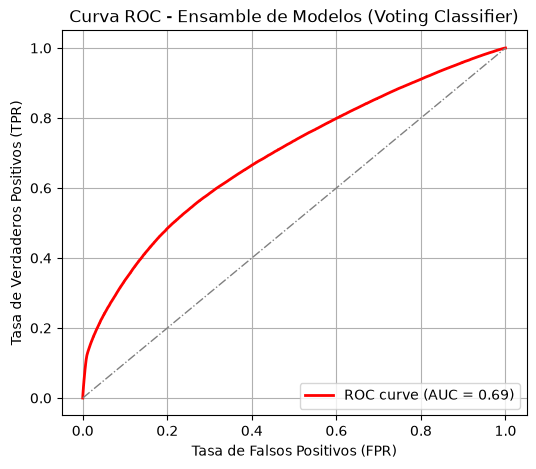

In [100]:
print(" Exactitud (Accuracy):", accuracy_score(y_test, y_pred_soft_voting))
print("\n Matriz de confusión:\n", confusion_matrix(y_test, y_pred_soft_voting))


# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_soft_voting)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='-.')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Ensamble de Modelos (Voting Classifier)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
